# Создание и оптимизация ResNet18

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

In [18]:
lst = [3, 64, 64]
new_lst = [lst]
print(tuple(lst[1:]))

(64, 64)


In [3]:
from enum import IntEnum

# user-defined index.
class usid(IntEnum):
    mdl_4x2_ReLU_Adam = 0
    mdl_3x2_ReLU_Adam = 1
    mdl_4x3_ReLU_Adam = 2
    mdl_4x1_ReLU_Adam = 3
    mdl_4x2_LeakyReLU_Adam = 4
    mdl_4x2_ELU_Adam = 5
    mdl_4x2_GELU_Adam = 6
    mdl_4x2_ReLU_AdamW = 7

# Имена моделей.
model_names = [e.name for e in usid]

Настройки форматирования графиков.

In [4]:
user_figsize = (10, 5)
user_fontsize = 16
legend_fontsize = 'large'
plot_titles = ["Losses", "Accuracy"]
plot_legend = ['train', 'validation']
plot_xlabel = "epoch"
plot_ylabels = ["loss", "accuracy"]
METRIC_NUM = len(plot_titles)

## Часть 2: Базовая архитектура ResNet18

### 2.5: Визуализация базовых результатов

In [5]:
log_dir = Path("./train_logs/")
log_names = [
    "train_log_customResNet18_Adam_ver1.json",
    "train_log_customResNet18_Adam_ver2.json"
    ]
DATA_NUM = len(log_names)
log_data = np.empty(DATA_NUM, dtype='object')
log_data_df = np.empty(DATA_NUM, dtype='object')
model_struct = np.empty(DATA_NUM, dtype='object')
for idx, name in enumerate(log_names):
    with open(log_dir / name, "r") as f:
        log_data[idx] = json.load(f)
        log_data_df[idx] = pd.DataFrame(log_data[idx].get("train_log"))
        model_struct[idx] = log_data[idx].get("model_architecture")

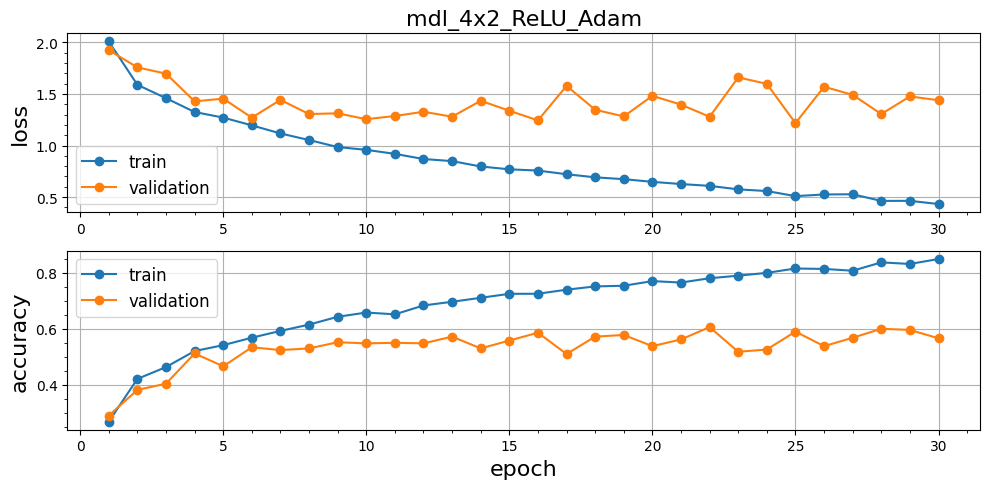

In [6]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=user_figsize)
#plt.title('4x2_ReLU', fontsize=user_fontsize)
for idx, ax in enumerate(axs):
    if idx == 0:
        ax.set_title(model_names[usid.mdl_4x2_ReLU_Adam], fontsize=user_fontsize)
    else:
        ax.set_xlabel(plot_xlabel, fontsize=user_fontsize)
    for m in range(METRIC_NUM):
        ax.plot(
            log_data_df[usid.mdl_4x2_ReLU_Adam].iloc[:,0], 
            log_data_df[usid.mdl_4x2_ReLU_Adam].iloc[:,2*m+idx+1],
            marker='o'
            )
    
    ax.set_ylabel(plot_ylabels[idx], fontsize=user_fontsize)
    ax.legend(plot_legend, fontsize=legend_fontsize)
    ax.grid()
    ax.minorticks_on()
    
plt.tight_layout()
plt.savefig('readme_img/loss_acc_4x2_ReLU_Adam.png', bbox_inches='tight')
plt.show()